# Ejercicio 1 — Análisis exploratorio de vinos tintos

---

> El dataset `winequality-red.csv` contiene un conjunto de variables relacionadas con propiedades fisicoquímicas que fueron determinadas sobre una serie de vinos de una misma variedad, así como un puntaje asignado en cada caso por un panel de enólogos en sesiones de cata. Importe el dataset al entorno de trabajo y realice cualquier tipo de limpieza y adecuación del mismo que considere necesaria para su posterior análisis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

In [2]:
df = pd.read_csv('../Datasets/winequality-red.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (1599, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [3]:
print('Tipos de datos:')
print(df.dtypes)
print('\nValores faltantes por columna:')
print(df.isnull().sum())
print(f'\nRegistros duplicados: {df.duplicated().sum()}')

df = df.drop_duplicates()
print(f'Shape tras eliminar duplicados: {df.shape}')

Tipos de datos:
fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object

Valores faltantes por columna:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

Registros duplicados: 240
Shape tras eliminar duplicados: (1359, 12)


---
## Ítem 1

> **Clasifique las variables del dataset en cualitativas, cuantitativas discretas y cuantitativas continuas.**

| Variable | Tipo |
|---|---|
| `quality` | Cuantitativa discreta (también puede interpretarse como ordinal/cualitativa) |
| `fixed acidity`, `volatile acidity`, `citric acid`, `residual sugar`, `chlorides`, `free sulfur dioxide`, `total sulfur dioxide`, `density`, `pH`, `sulphates`, `alcohol` | Cuantitativas continuas |

---
## Ítem 2

> **El 25% de los vinos del dataset tiene un contenido de alcohol superior a… ¿qué valor?**

In [4]:
# Si el 25% tiene MÁS de cierto valor, ese valor es el percentil 75 (Q3)
p75_alcohol = df['alcohol'].quantile(0.75)
print(f'El 25% de los vinos tiene un contenido de alcohol superior a: {p75_alcohol:.2f}%')

El 25% de los vinos tiene un contenido de alcohol superior a: 11.10%


---
## Ítem 3

> **Realice una tabla en la que se presenten, para las variables densidad y pH, *únicamente* las siguientes medidas descriptivas: media, mediana, desvío estándar y rango intercuartil. A continuación, responda a las siguientes preguntas *sin realizar ningún gráfico:***
> - ¿Cómo describiría ambas distribuciones en relación a sus características de simetría?
> - ¿Cuál de los dos conjuntos de observaciones (densidad o pH) presenta mayor variabilidad?

In [5]:
cols = ['density', 'pH']
tabla = df[cols].agg(['mean', 'median', 'std'])
tabla.index = ['Media', 'Mediana', 'Desvío estándar']

iqr = pd.Series(
    {c: df[c].quantile(0.75) - df[c].quantile(0.25) for c in cols},
    name='Rango intercuartil'
)
tabla = pd.concat([tabla, iqr.to_frame().T])
tabla.round(5)

,density,pH
Media,0.99671,3.30979
Mediana,0.99670,3.31000
Desvío estándar,0.00187,0.15504
Rango intercuartil,0.00222,0.19000


**Simetría:**
- **Densidad**: la media y la mediana son prácticamente iguales → distribución aproximadamente simétrica.
- **pH**: la media y la mediana también son muy cercanas → distribución aproximadamente simétrica.

**Variabilidad:**
- Comparando los rangos intercuartiles en escala relativa, el **pH** presenta mayor variabilidad relativa que la densidad (su RIC representa un porcentaje mayor respecto a su valor central).

---
## Ítem 4

> **Represente la distribución de las observaciones de la variable contenido de alcohol (`alcohol`) a través de un boxplot.** *Sugerencia: utilice la función `sns.boxplot()` de la librería seaborn.* Basándose en el gráfico, ¿cuál de las siguientes medidas de posición o centralidad (media aritmética/mediana) le parece más adecuada para describir a esta variable?

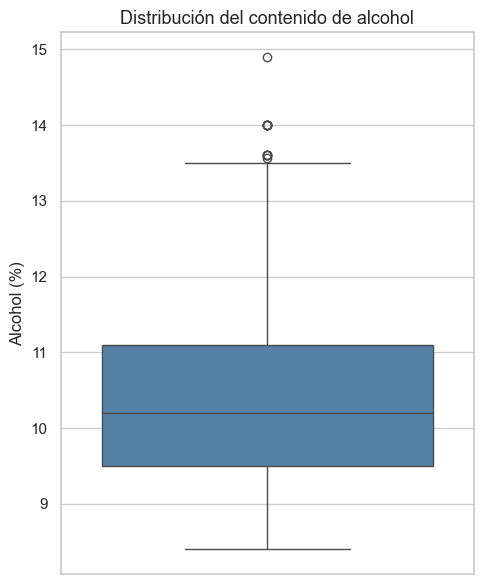

Media:   10.432
Mediana: 10.200


In [6]:
fig, ax = plt.subplots(figsize=(5, 6))
sns.boxplot(y=df['alcohol'], ax=ax, color='steelblue')
ax.set_title('Distribución del contenido de alcohol', fontsize=13)
ax.set_ylabel('Alcohol (%)')
plt.tight_layout()
plt.show()

print(f"Media:   {df['alcohol'].mean():.3f}")
print(f"Mediana: {df['alcohol'].median():.3f}")

El boxplot muestra una distribución con **sesgo positivo** (cola hacia valores altos). La **mediana** es más representativa que la media aritmética, ya que la media se ve arrastrada hacia arriba por los valores extremos.

---
## Ítem 5

> **Realice una tabla de frecuencias para resumir la distribución de los vinos del dataset en función del puntaje asignado según su calidad (`quality`).**
> - ¿Cuál de los puntajes fue recibido por una mayor cantidad de vinos?
> - ¿Qué porcentaje de los vinos de la muestra recibieron la calificación más baja?

In [7]:
freq_abs = df['quality'].value_counts().sort_index()
freq_rel = (freq_abs / len(df) * 100).round(2)
freq_acum = freq_rel.cumsum().round(2)

tabla_freq = pd.DataFrame({
    'Frecuencia absoluta': freq_abs,
    'Frecuencia relativa (%)': freq_rel,
    'Frecuencia acumulada (%)': freq_acum
})
tabla_freq.index.name = 'Puntaje (quality)'
print(tabla_freq)

print(f"\nPuntaje más frecuente: {freq_abs.idxmax()} ({freq_abs.max()} vinos)")
calif_min = freq_abs.index.min()
print(f"Porcentaje de vinos con la calificación más baja ({calif_min}): {freq_rel[calif_min]}%")

                   Frecuencia absoluta  Frecuencia relativa (%)  \
Puntaje (quality)                                                 
3                                   10                     0.74   
4                                   53                     3.90   
5                                  577                    42.46   
6                                  535                    39.37   
7                                  167                    12.29   
8                                   17                     1.25   

                   Frecuencia acumulada (%)  
Puntaje (quality)                            
3                                      0.74  
4                                      4.64  
5                                     47.10  
6                                     86.47  
7                                     98.76  
8                                    100.01  

Puntaje más frecuente: 5 (577 vinos)
Porcentaje de vinos con la calificación más baja (3): 0.7